In [5]:
import shap

print(shap.__version__)

0.52.0


In [6]:
import shap

print(shap.__version__)

0.52.0


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.ensemble import IsolationForest

In [9]:
import os

print(os.getcwd())

c:\Users\jayas\OneDrive\Documents\AI_Research\notebooks


In [10]:
import os

print(os.listdir("../data"))

FileNotFoundError: [WinError 3] The system cannot find the path specified: '../data'

In [11]:
import os

print(os.listdir(".."))

['.git', 'datasets', 'explainable_log_anomaly_detection', 'figures', 'notebooks', 'papers', 'README.md', 'results']


In [12]:
df = pd.read_csv("../data/HDFS_2k_Structured.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../data/HDFS_2k_Structured.csv'

In [13]:
df = pd.read_csv("../HDFS_2k_Structured.csv")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../HDFS_2k_Structured.csv'

In [14]:
import os

print(os.getcwd())
print(os.path.exists("../HDFS_2k_Structured.csv"))

c:\Users\jayas\OneDrive\Documents\AI_Research\notebooks
False


In [15]:
import os

print(os.getcwd())
print(os.listdir(".."))

c:\Users\jayas\OneDrive\Documents\AI_Research\notebooks
['.git', 'datasets', 'explainable_log_anomaly_detection', 'figures', 'notebooks', 'papers', 'README.md', 'results']


In [ ]:
notebooksimport glob

print(glob.glob("../*.csv"))
print(glob.glob("../../*.csv"))

[]
[]


In [17]:
import os

print(os.listdir("../datasets"))

['HDFS_2k.log', 'HDFS_2k_structured.csv']


In [18]:
df = pd.read_csv("../datasets/HDFS_2k_structured.csv")

df.head()

,Date,Time,Thread_ID,Level,Component,Message
0,81109,203615,148,INFO,dfs.DataNode$PacketResponder:,PacketResponder 1 for block blk_38865049064139...
1,81109,203807,222,INFO,dfs.DataNode$PacketResponder:,PacketResponder 0 for block blk_-6952295868487...
2,81109,204005,35,INFO,dfs.FSNamesystem:,BLOCK* NameSystem.addStoredBlock: blockMap upd...
3,81109,204015,308,INFO,dfs.DataNode$PacketResponder:,PacketResponder 2 for block blk_82291938032499...
4,81109,204106,329,INFO,dfs.DataNode$PacketResponder:,PacketResponder 2 for block blk_-6670958622368...


In [19]:
df["Message_Length"] = df["Message"].str.len()

df["Has_Block_ID"] = df["Message"].str.contains("blk_", regex=False).astype(int)

df["Has_PacketResponder"] = df["Message"].str.contains("PacketResponder", regex=False).astype(int)

df["Has_Error"] = df["Message"].str.contains("error", case=False, regex=False).astype(int)

df["Is_WARN"] = (df["Level"] == "WARN").astype(int)

In [20]:
features = [
    "Message_Length",
    "Has_Block_ID",
    "Has_PacketResponder",
    "Has_Error",
    "Is_WARN"
]

X = df[features]

In [21]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    contamination=0.05,
    random_state=42
)

model.fit(X)

,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [22]:
explainer = shap.TreeExplainer(model)

In [23]:
shap_values = explainer.shap_values(X)

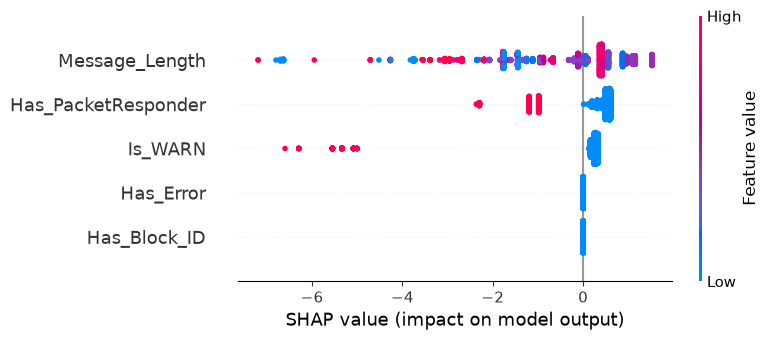

In [24]:
shap.summary_plot(shap_values, X)